# Postprocessing

In [7]:
import flopy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from rtmf6.postprocessing.output_reader import ShelveViewer
import numpy as np

viewer = ShelveViewer('rtmf6.toml') ## load from selected output

In [8]:
#%% LOAD MODEL
sim_name = 'ex10_dens'
gwf_name = f'gwf_{sim_name}'
gwt_name = f'gwt_{sim_name}'
gws_name = f'gws_{sim_name}' # salinity for density simulation
sim_ws = './mf6'

sim = flopy.mf6.MFSimulation.load(
    sim_name, 
    'mf6', 
    exe_name='mf6', 
    sim_ws=sim_ws
)

gwf = sim.get_model(gwf_name)

mg = gwf.modelgrid
x = mg.xcellcenters[0,:]
z = mg.zcellcenters
z=z[:,0,0]

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package ic...
    loading package wel...
    loading package ghb...
    loading package oc...
    loading package buy...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package ssm...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package oc...
  loading model gwt6...
    loading package dis...
    loading package ic...
    loading package ssm...
    loading package adv...
    loading package dsp...
    loading package mst...
    loading package oc...
  loading exchange package gwf-gwt_exg_0...
  loading exchange package gwf-gwt_exg_1...
  loading solution package gwf_ex10_dens...
  loading solution package gwt_ex10_dens...
  loading solution package gws_ex10_dens...


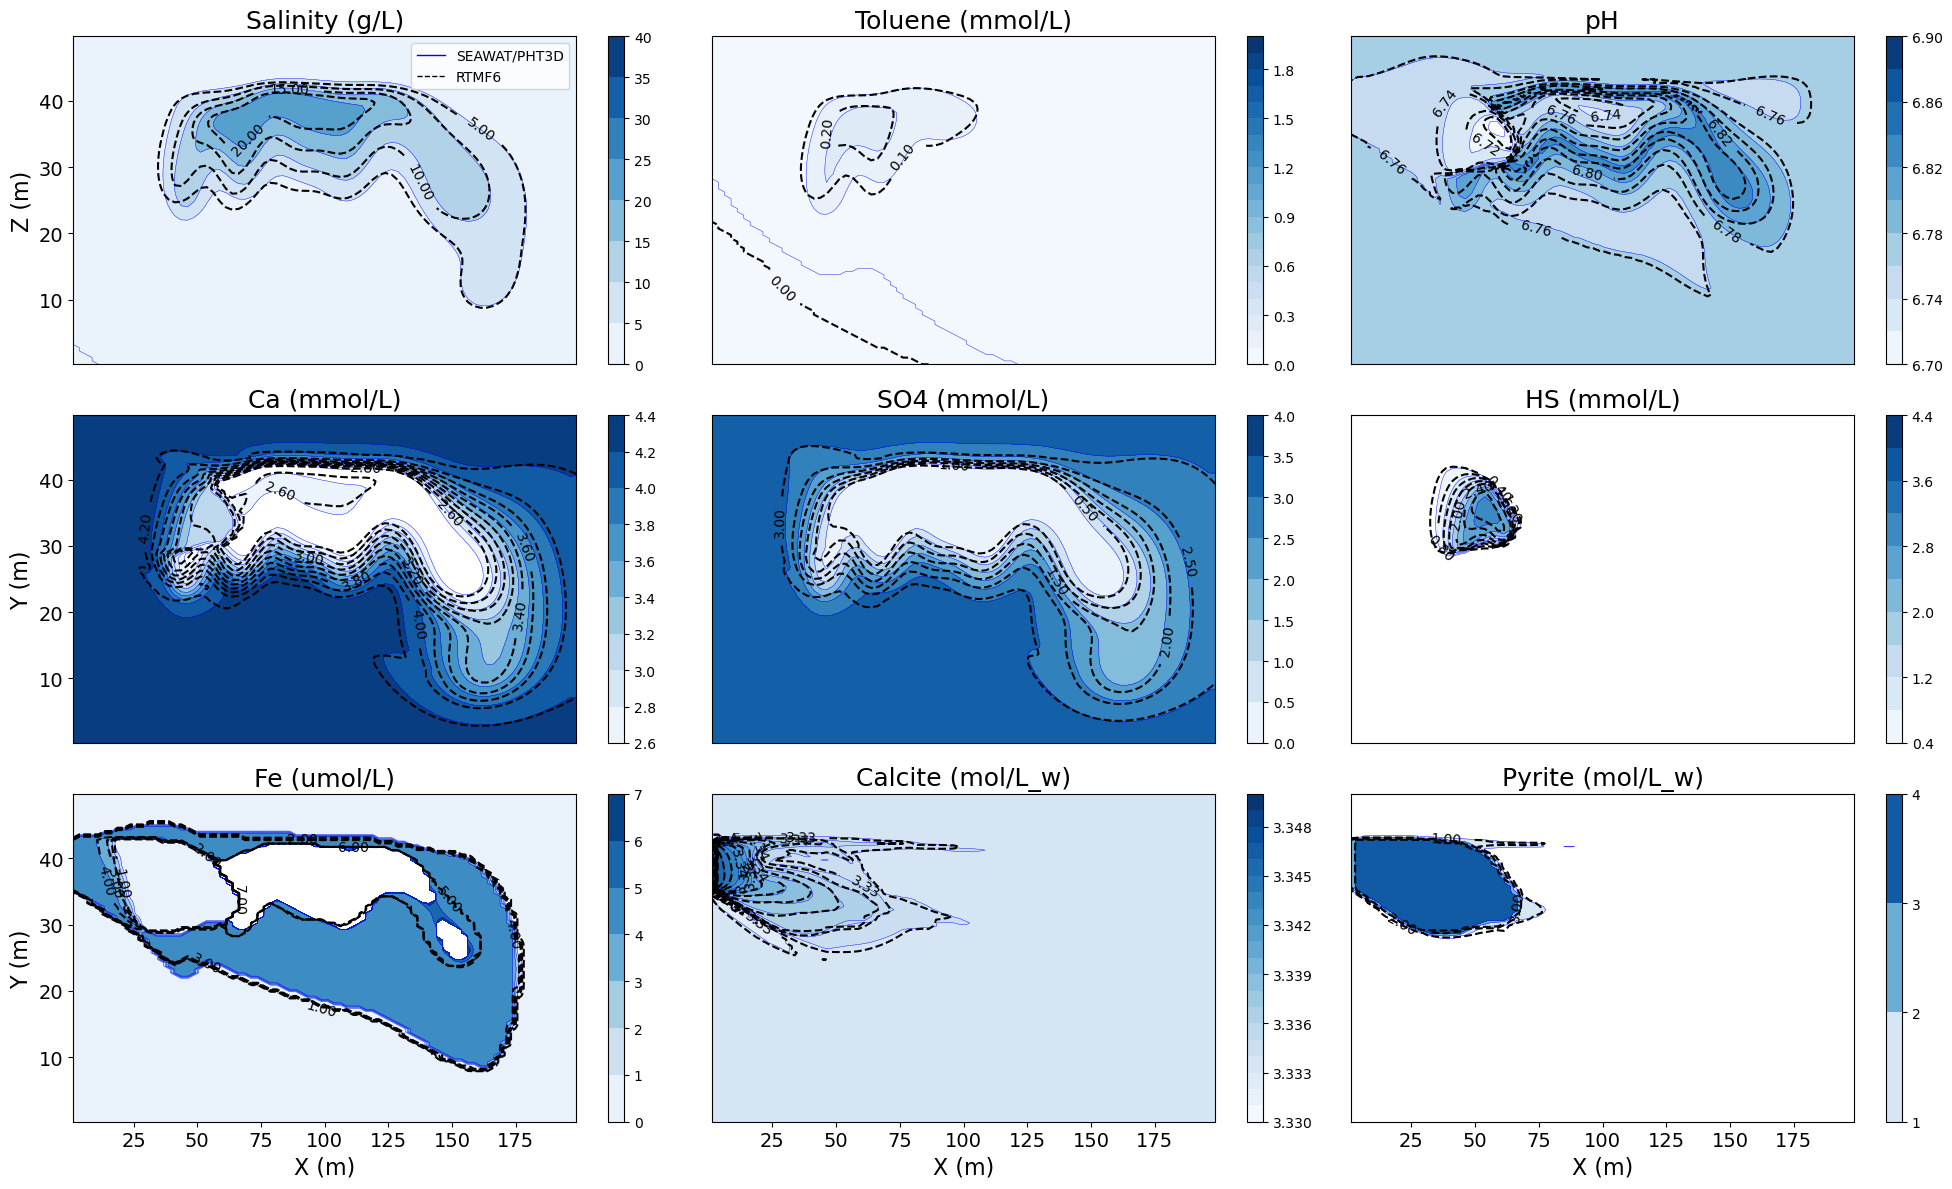

In [9]:
#%% Plot
timestep = 10000

plt.figure(1,figsize=(20,12))
pht3d_path ='./pht3d_results'

### SALINITY
plt.subplot(3,3,1)

fname = "./seawat_results/MT3D001.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:],np.arange(0.0,41,5),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:],np.arange(0.0,41,5),colors='b',linewidths=0.3)


#path = './'
#ucn_file = path + f"{gws_name}.ucn"
#ucnobj = flopy.utils.HeadFile(ucn_file, text="CONCENTRATION")
#c_rtmf6 = ucnobj.get_alldata()

species = 'Tolu'
path = './.internal/component_models/'+species+'/'
ucn_file = path + f"{gws_name}.ucn"
ucnobj = flopy.utils.HeadFile(ucn_file, text="CONCENTRATION")
c_rtmf6 = ucnobj.get_alldata()

csp=plt.contour(x,z,c_rtmf6[-1,:,0,:],np.arange(0.0,41,5),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')


legend_lines = [
    Line2D([0], [0], color='b', lw=1, label='SEAWAT/PHT3D'),
    Line2D([0], [0], color='k', lw=1, linestyle='--', label='RTMF6')
]

plt.legend(handles=legend_lines, loc=1)

plt.title('Salinity (g/L)',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Z (m)',fontsize=16)
plt.xticks([])
plt.yticks(fontsize=14)

### TOLU
plt.subplot(3,3,2)

fname = pht3d_path + "/PHT3D001.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(0.0,2.1,0.1),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(0.0,2.1,0.1),colors='b',linewidths=0.3)


species = 'Tolu'
path = './.internal/component_models/'+species+'/'
ucn_file = path + f"{gwt_name}.ucn"
ucnobj = flopy.utils.HeadFile(ucn_file, text="CONCENTRATION")
c_rtmf6 = ucnobj.get_alldata()

csp=plt.contour(x,z,c_rtmf6[-1,:,0,:]*1000,np.arange(0.0,2.1,0.1),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')


#legend_lines = [
#    Line2D([0], [0], color='b', lw=1, label='PHT3D'),
#    Line2D([0], [0], color='k', lw=1, linestyle='--', label='RTMF6')
#]

#plt.legend(handles=legend_lines, loc=1)

plt.title('Toluene (mmol/L)',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Z (m)',fontsize=16)
plt.xticks([])
plt.yticks([])


### pH
plt.subplot(3,3,3)
fname = pht3d_path + "/PHT3D018.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:],np.arange(6.7,6.9,0.02),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:],np.arange(6.7,6.9,0.02),colors='b',linewidths=0.3)


pH = viewer.selected_output.selected_output_1.get_value(timestep)['pH']

csp=plt.contour(x,z,pH[:,0,:],np.arange(6.7,6.9,0.02),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

plt.title('pH',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Y (m)',fontsize=16)
plt.xticks([])
plt.yticks([])


### CA
plt.subplot(3,3,4)
fname = pht3d_path + "/PHT3D005.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(2.6,4.6,0.2),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(2.6,4.6,0.2),colors='b',linewidths=0.3)


species = 'Ca'
path = './.internal/component_models/'+species+'/'
ucn_file = path + f"{gwt_name}.ucn"
ucnobj = flopy.utils.HeadFile(ucn_file, text="CONCENTRATION")
c_rtmf6 = ucnobj.get_alldata()

csp=plt.contour(x,z,c_rtmf6[-1,:,0,:]*1000,np.arange(2.6,4.6,0.2),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

plt.title('Ca (mmol/L)',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Y (m)',fontsize=16)
plt.xticks([])
plt.yticks(fontsize=14)



### S(6)
plt.subplot(3,3,5)
fname = pht3d_path + "/PHT3D017.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(0.0,4.5,0.5),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(0.0,4.5,0.5),colors='b',linewidths=0.3)

SO4 = viewer.selected_output.selected_output_1.get_value(timestep)['S(6)']

csp=plt.contour(x,z,SO4[:,0,:]*1000,np.arange(0.0,4.5,0.5),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

plt.title('SO4 (mmol/L)',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Y (m)',fontsize=16)
plt.xticks([])
plt.yticks([])


### S(-2)
plt.subplot(3,3,6)
fname = pht3d_path + "/PHT3D016.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(0.4,4.5,0.4),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(0.4,4.5,0.4),colors='b',linewidths=0.3)

HS = viewer.selected_output.selected_output_1.get_value(timestep)['S(-2)']

csp=plt.contour(x,z,HS[:,0,:]*1000,np.arange(0.4,4.5,0.4),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

plt.title('HS (mmol/L)',fontsize=18)
#plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Y (m)',fontsize=16)
plt.xticks([])
plt.yticks([])




### Fe(2)
plt.subplot(3,3,7)
fname = pht3d_path + "/PHT3D007.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:]*1000e3,[0.0,1,2,3,4,5,6,7],cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:]*1000e3,[0.0,1,2,3,4,5,6,7],colors='b',linewidths=0.3)


species = 'Fe'
path = './.internal/component_models/'+species+'/'
ucn_file = path + f"{gwt_name}.ucn"
ucnobj = flopy.utils.HeadFile(ucn_file, text="CONCENTRATION")
c_rtmf6 = ucnobj.get_alldata()

csp=plt.contour(x,z,c_rtmf6[-1,:,0,:]*1000e3,[0.0,1,2,3,4,5,6,7],colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')

plt.title('Fe (umol/L)',fontsize=18)
plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Y (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


## Calcite
plt.subplot(3,3,8)
fname = pht3d_path + "/PHT3D020.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:],np.arange(3.33,3.35,0.001),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:],np.arange(3.33,3.35,0.001),colors='b',linewidths=0.3)

Calcite = viewer.selected_output.selected_output_1.get_value(timestep)['Calcite']

csp=plt.contour(x,z,Calcite[:,0,:],np.arange(3.33,3.35,0.001),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')


plt.title('Calcite (mol/L_w)',fontsize=18)
plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Y (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks([])


'''
## Goethite
plt.subplot(3,3,8)
fname = pht3d_path + "/PHT3D021.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(1,5,1),cmap='Blues')
csl=plt.contour(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(1,5,1),colors='b',linewidths=0.3)


Goethite = viewer.selected_output.selected_output_1.get_value(timestep)['Goethite']

csp=plt.contour(x,z,Goethite[:,0,:]*1000,np.arange(1,5,1),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')


plt.title('Goethite (mmol/L_w)',fontsize=18)
plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Y (m)',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
'''


## Pyrite
plt.subplot(3,3,9)
fname = pht3d_path + "/PHT3D022.UCN"
ucnobj = flopy.utils.UcnFile(fname, precision='auto')
times = ucnobj.get_times()
c_pht3d= ucnobj.get_alldata()
ucnobj.close() 

cs=plt.contourf(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(1,5,1),cmap='Blues')
plt.colorbar()
csl=plt.contour(x,z,c_pht3d[-1,:,0,:]*1000,np.arange(1,5,1),colors='b',linewidths=0.3)


Pyrite = viewer.selected_output.selected_output_1.get_value(timestep)['Pyrite']

csp=plt.contour(x,z,Pyrite[:,0,:]*1000,np.arange(1,5,1),colors='k',linestyles='dashed')
plt.clabel(csp,fmt='%1.2f')


plt.title('Pyrite (mol/L_w)',fontsize=18)
plt.xlabel('X (m)',fontsize=16)
#plt.ylabel('Y (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks([])


plt.tight_layout()
plt.savefig('../results/PHT3D_RTMF6_compare.png')
#plt.savefig('./PHT3D_RTMF6_compare.png')